In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os 
import importlib
from scipy.signal import welch


if 'oscillator_model' not in os.listdir(): 
    os.chdir('..')

import oscillator_model.oscillator
importlib.reload(oscillator_model.oscillator)
from oscillator_model.oscillator import Oscillator

import oscillator_model.fitting
importlib.reload(oscillator_model.fitting)
from oscillator_model.fitting import *


import oscillator_model.utils
importlib.reload(oscillator_model.utils)
from oscillator_model.utils import *

In [3]:
f_off_pts_NS = np.array([1e0, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6])
L_dBc_pts_NS = np.array([-111.2, -140.0, -156.7, -161.1, -162.0, -162.2, -163.1])

tau_pts_NS = np.array([1.0, 2.0, 4.0, 8.0, 10.0, 20.0, 40.0, 80.0, 100.0, 200.0, 400.0, 800.0, 1000.0, 2000.0, 4000.0])
sigma_y_NS = np.array([5.10e-13, 4.76e-13, 4.67e-13, 4.80e-13, 4.91e-13, 5.27e-13, 5.52e-13, 5.84e-13, 5.99e-13, 7.27e-13, 9.65e-13, 1.61e-12, 1.94e-12, 3.66e-12, 7.37e-12])

f_all = np.logspace(-8, 6, 5000)
NS_coeffs, NS_drift = fit_oscillator_coeffs_joint_drift(f_off_pts_NS, L_dBc_pts_NS, tau_pts_NS, sigma_y_NS, f_all, 10e6)


In [4]:
N_runs = 6

oscs_slow = {}
for i in range(N_runs):
    oscs_slow[i] = Oscillator(
        fosc=10e6, fc=1e9, fs=20, T=100.0,
        n_periods=20, start_period=0, n_captures=1,
        coeffs_lin=NS_coeffs,
        include_drift=True, ppb_day=NS_drift,
    )
    oscs_slow[i].realize_phase_error()

oscs_fast = {}
for i in range(N_runs):
    oscs_fast[i] = Oscillator(
        fosc=10e6, fc=1e9, fs=100e6, T=1e-3,
        n_periods=1, start_period=0, n_captures=1,
        coeffs_lin=NS_coeffs,
        include_drift=False,
        start_phi_out_0=False,
        )
    oscs_fast[i].realize_phase_error()


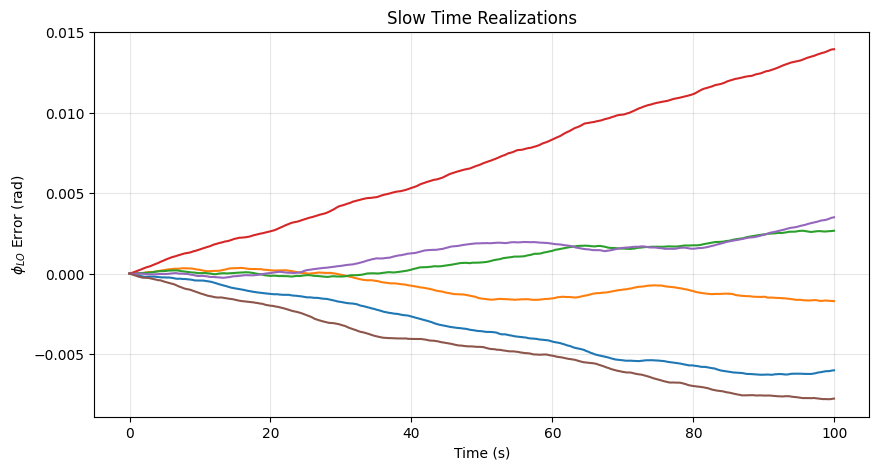

In [5]:
plt.figure(figsize=(10, 5))
for i in range(N_runs):
    phi = oscs_slow[i].phi_out - oscs_slow[i].phi_out[0]
    plt.plot(oscs_slow[i].t_out, phi)
plt.xlabel('Time (s)')
plt.ylabel(r'$\phi_{LO}$ Error (rad)')
plt.title('Slow Time Realizations')
plt.grid(True, alpha=0.3)

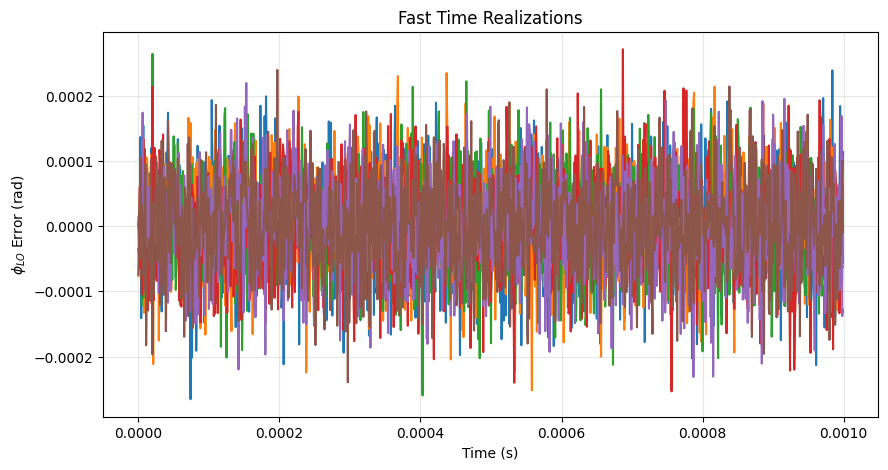

In [6]:
plt.figure(figsize=(10, 5))
for i in range(N_runs):
    plt.plot(oscs_fast[i].t_out[::100], oscs_fast[i].phi_out[::100])
plt.xlabel('Time (s)')
plt.ylabel(r'$\phi_{LO}$ Error (rad)')
plt.title('Fast Time Realizations')
plt.grid(True, alpha=0.3)

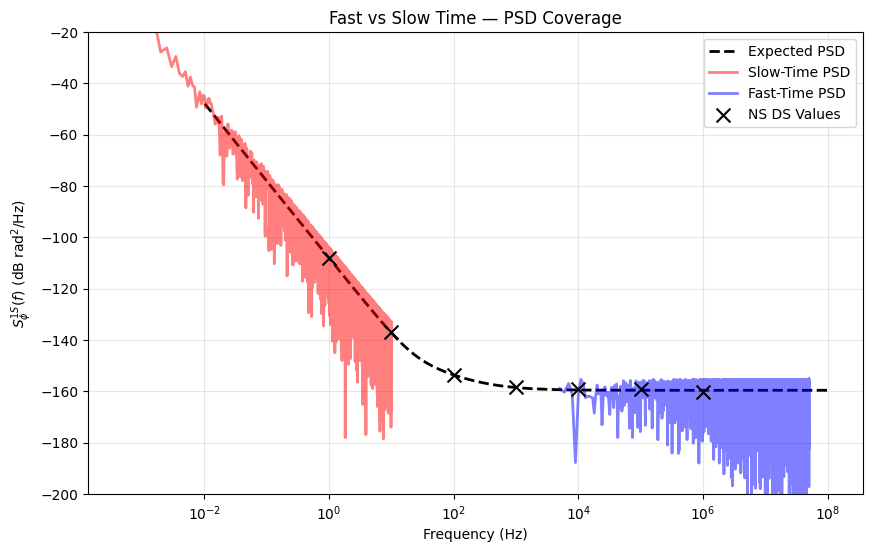

In [7]:

freqs_slow, psd_slow = welch(oscs_slow[0].phi_lo, fs=oscs_slow[0].fs, window='hann', nperseg=len(oscs_slow[0].phi_lo), 
                             noverlap=len(oscs_slow[0].phi_lo) // 2, detrend=False, scaling='density')

freqs_fast, psd_fast = welch(oscs_fast[0].phi_lo, fs=oscs_fast[0].fs, window='hann', nperseg=len(oscs_fast[0].phi_lo), 
                             noverlap=len(oscs_fast[0].phi_lo) // 2, detrend=False, scaling='density')

fgrid = np.logspace(-2, 8, 1000)
_, S1_model = oscs_slow[0].S1(fgrid)

plt.figure(figsize=(10, 6))
plt.semilogx(fgrid[1:], lin_to_db(S1_model[1:]), '--', lw=2, label='Expected PSD', color='black')
plt.semilogx(freqs_slow, lin_to_db(psd_slow), color='red', alpha=0.5, lw=2, label='Slow-Time PSD')
plt.semilogx(freqs_fast[5:], lin_to_db(psd_fast[5:]), color='blue', alpha=0.5, lw=2, label='Fast-Time PSD')
plt.scatter(f_off_pts_NS, lin_to_db(dBc_to_S1(L_dBc_pts_NS)), marker='x', color='black', s=100, zorder=10, label='NS DS Values')
plt.xlabel('Frequency (Hz)')
plt.ylabel(r'$S_\phi^{1S}(f)$ (dB rad$^2$/Hz)')
plt.title('Fast vs Slow Time — PSD Coverage')
plt.ylim([-200, -20])
plt.legend()
plt.grid(True, which='both', alpha=0.3)

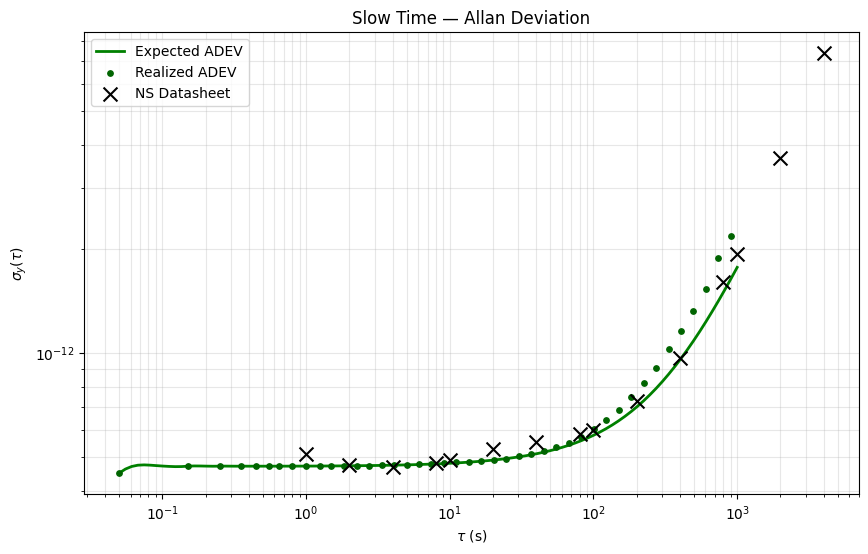

In [8]:
slow = oscs_slow[0]
taus_theory, adev_theory = slow.allan_dev_from_phase_psd()
taus_real, adev_real = slow.allan_dev_from_phase_realization(phi_type='lo')

plt.figure(figsize=(10, 6))
plt.loglog(taus_theory, adev_theory, color='green', lw=2, label='Expected ADEV')
plt.scatter(taus_real[::2], adev_real[::2], s=15, color='darkgreen', marker='o', zorder=10, label='Realized ADEV')
plt.scatter(tau_pts_NS, sigma_y_NS, marker='x', color='black', s=100, zorder=10, label='NS Datasheet')
plt.xlabel(r'$\tau$ (s)')
plt.ylabel(r'$\sigma_y(\tau)$')
plt.title('Slow Time — Allan Deviation')
plt.legend()
plt.grid(True, which='both', alpha=0.3)